
*   Los bosques son fáciles de programar
*   Todas las variables deben ser numéricas
* No afecta como hagas la transformación a numérica.




In [65]:
import pandas as pd
df = pd.read_csv('publicidad.csv')
df

,tv,radio,periodico,ventas
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


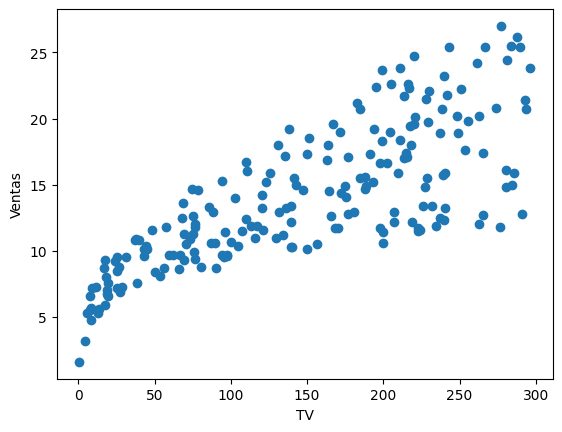

In [66]:
import matplotlib.pyplot as plt
plt.scatter(df['tv'], df['ventas'])
plt.xlabel('TV')
plt.ylabel('Ventas')
plt.show()

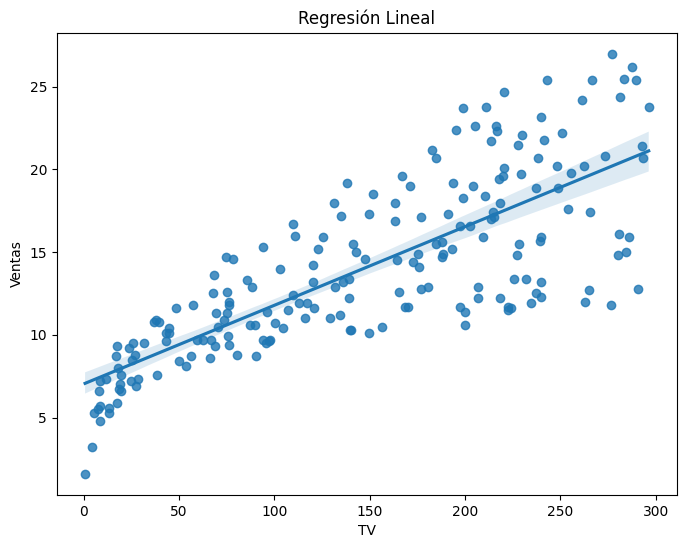

Coeficiente de Correlación (TV vs Ventas): 0.78


In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(8, 6))
sns.regplot(x='tv', y='ventas', data=df)
plt.xlabel('TV')
plt.ylabel('Ventas')
plt.title('Regresión Lineal')
plt.show()

cc = np.corrcoef(df['tv'], df['ventas'])[0, 1]
print(f"Coeficiente de Correlación (TV vs Ventas): {cc:.2f}")

Esta recta se construye buscando la mejor pendiente y mejor altura de la recta.
* Lo más cerca de todos los puntos
*Estadistica -> conjunto de datos completo
* Aprendizaje -> utiliza una parte para entrenar y otro para probar


# 1.- Modelo Estadístico

In [68]:

import statsmodels.api as sm

X = df[['tv', 'radio']]  #se quitó 'periodico'
#X = df.drop('ventas', axis=1)
y = df['ventas']
# A la matriz de predictores se le añade una columna de 1s para el intercepto del modelo
X = sm.add_constant(X, prepend=True) #B0
modelo = sm.OLS(endog=y, exog=X) #caja negra que minimiza
modelo = modelo.fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                 ventas   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     859.6
Date:                Sat, 04 Oct 2025   Prob (F-statistic):           4.83e-98
Time:                        01:31:48   Log-Likelihood:                -386.20
No. Observations:                 200   AIC:                             778.4
Df Residuals:                     197   BIC:                             788.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9211      0.294      9.919      0.0

In [69]:
X

,const,tv,radio
0,1.0,230.1,37.8
1,1.0,44.5,39.3
2,1.0,17.2,45.9
3,1.0,151.5,41.3
4,1.0,180.8,10.8
...,...,...,...
195,1.0,38.2,3.7
196,1.0,94.2,4.9
197,1.0,177.0,9.3
198,1.0,283.6,42.0


In [70]:
# ¿De cuánto serían las ventas si se invierte $50 en tv y $30 en radio?
new = pd.DataFrame({'const': [1], 'tv': [50], 'radio': [30]})  #se quitó 'periodico'
ventas_predichas = modelo.predict(new)
print(f"Ventas predichas: {ventas_predichas[0]}")

Ventas predichas: 10.84866746606822


In [71]:
#saca el RSME
from sklearn.metrics import mean_squared_error
import numpy as np
y_pred = modelo.predict(X)
rmse = np.sqrt(mean_squared_error(y, y_pred))
print(f"RMSE: {rmse}")

RMSE: 1.668703059366193


# 2.- Método de Aprendizaje de Máquina

In [72]:

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error

import pandas as pd
df = pd.read_csv('publicidad.csv')
X = df[['tv', 'radio']]
y = df['ventas']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
modelo = LinearRegression()
modelo.fit(X = X_train, y = y_train)

LinearRegression()

In [73]:
# Información del modelo

print(f"Intercept: {modelo.intercept_}")
print(f"Coeficiente: {list(zip(modelo.feature_names_in_, modelo.coef_))}")
print(f"Coeficiente de determinación R^2:", modelo.score(X, y))

Intercept: 3.028255250783305
Coeficiente: [('tv', np.float64(0.04472830196637739)), ('radio', np.float64(0.19066726454072783))]
Coeficiente de determinación R^2: 0.896852666661469


In [74]:
coefficients = modelo.coef_
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': coefficients}).sort_values(by='Importance', ascending=False)
print(importance_df)

  Feature  Importance
1   radio    0.190667
0      tv    0.044728




```
     Feature  Importance
1      radio    0.189195
0         tv    0.044730
2  periodico    0.002761
```

- Radio es la más importante (casi 100 veces más importante que periódico)
- Periodico es el menos importante

* DEBES definir tu punto de corte para saber donde descartar (importante cuando son muchas variables)

*QUITAMOS EL PERIODICO DE LOS PASOS ANTERIORES*



In [75]:
y_pred = modelo.predict(X_test)
print(f"RMSE: {root_mean_squared_error(y_test, y_pred)}")

RMSE: 1.7714254173033517


*RMSE -> CUADRO DE LOS ERRORES AL CUADRO*

***

# 3.- Bosques Aleatorios

In [76]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
X = df[['tv', 'radio', 'periodico']]
y = df['ventas']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

regressor = RandomForestRegressor(n_estimators=1000, random_state=42) #LA CAJA NEGRA
regressor.fit(X_train, y_train)

RandomForestRegressor(n_estimators=1000, random_state=42)

In [77]:
y_pred = regressor.predict(X_test)
print(f"RMSE: {root_mean_squared_error(y_test, y_pred)}")

RMSE: 0.7500779319510714


In [78]:

feature_importances = {name: score for name, score in zip(list(df), regressor.feature_importances_)}
feature_importances_sorted = pd.Series(feature_importances).sort_values(ascending=False)
feature_importances_sorted.head(20)

,0
tv,0.626761
radio,0.360358
periodico,0.012881


In [79]:
X = df[['tv','radio']]
y = df['ventas']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

regressor = RandomForestRegressor(n_estimators=1000, random_state=42,max_depth=3)
regressor.fit(X_train, y_train)

RandomForestRegressor(max_depth=3, n_estimators=1000, random_state=42)

In [80]:
y_pred = regressor.predict(X_test)
print(f"RMSE: {root_mean_squared_error(y_test, y_pred)}")

RMSE: 1.3058045761847072


In [81]:
# ¿De cuánto serían las ventas si se invierte $50 en tv y $30 en radio?

new_data = pd.DataFrame({'tv': [50], 'radio': [30]})
predicted_sales = regressor.predict(new_data)
print(f"Predicted sales: {predicted_sales[0]}")

Predicted sales: 11.48941505199316


In [ ]:
# Visualizando solo un árbol

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

tree_to_plot = regressor.estimators_[1]

# Plot the decision tree
plt.figure(figsize=(20, 10))
plot_tree(tree_to_plot, feature_names=df.columns.tolist(), filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree from Random Forest")
plt.show()

In [83]:
X_train

,tv,radio
79,116.0,7.7
197,177.0,9.3
38,43.1,26.7
24,62.3,12.6
122,224.0,2.4
...,...,...
106,25.0,11.0
14,204.1,32.9
92,217.7,33.5
179,165.6,10.0


In [84]:
X_train [X_train['tv'] <= 150]

,tv,radio
79,116.0,7.7
38,43.1,26.7
24,62.3,12.6
195,38.2,3.7
29,70.6,16.0
...,...,...
116,139.2,14.3
87,110.7,40.6
121,18.8,21.7
71,109.8,14.3


# CONJUNTO DE DATOS CARDECO

In [85]:
import pandas as pd
df = pd.read_csv('cardekho.csv')
df

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda,2014,450000,141000,Diesel,Individual,Manual,Second Owner
...,...,...,...,...,...,...,...,...
4335,Hyundai,2014,409999,80000,Diesel,Individual,Manual,Second Owner
4336,Hyundai,2014,409999,80000,Diesel,Individual,Manual,Second Owner
4337,Maruti,2009,110000,83000,Petrol,Individual,Manual,Second Owner
4338,Hyundai,2016,865000,90000,Diesel,Individual,Manual,First Owner


In [90]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [91]:
df.fuel = df.fuel.map({'Petrol': 0, 'Diesel': 1, 'CNG': 2})
df.seller_type = df.seller_type.map({'Dealer': 0, 'Individual': 1})
df.transmission = df.transmission.map({'Manual': 0, 'Automatic': 1})
df.owner = df.owner.map({'First Owner': 0, 'Second Owner': 1, 'Third Owner': 2, 'Fourth & Above Owner': 3})
df.info()
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           4340 non-null   object 
 1   year           4340 non-null   int64  
 2   selling_price  4340 non-null   int64  
 3   km_driven      4340 non-null   int64  
 4   fuel           4316 non-null   float64
 5   seller_type    4238 non-null   float64
 6   transmission   4340 non-null   int64  
 7   owner          4323 non-null   float64
dtypes: float64(3), int64(4), object(1)
memory usage: 271.4+ KB


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti,2007,60000,70000,0.0,1.0,0,0.0
1,Maruti,2007,135000,50000,0.0,1.0,0,0.0
2,Hyundai,2012,600000,100000,1.0,1.0,0,0.0
3,Datsun,2017,250000,46000,0.0,1.0,0,0.0
4,Honda,2014,450000,141000,1.0,1.0,0,1.0
...,...,...,...,...,...,...,...,...
4335,Hyundai,2014,409999,80000,1.0,1.0,0,1.0
4336,Hyundai,2014,409999,80000,1.0,1.0,0,1.0
4337,Maruti,2009,110000,83000,0.0,1.0,0,1.0
4338,Hyundai,2016,865000,90000,1.0,1.0,0,0.0


In [104]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

X = df[['year', 'fuel', 'km_driven', 'seller_type','transmission','owner']]
y = df['selling_price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

regressor = RandomForestRegressor(n_estimators=1000, random_state=42) #LA CAJA NEGRA
regressor.fit(X_train, y_train)

RandomForestRegressor(n_estimators=1000, random_state=42)

In [105]:
y_pred = regressor.predict(X_test)
print(f"RMSE: {root_mean_squared_error(y_test, y_pred)}")

RMSE: 390539.49675492337


In [111]:
feature_importances = {name: score for name, score in zip(list(X_train), regressor.feature_importances_)}
feature_importances_sorted = pd.Series(feature_importances).sort_values(ascending=False)
feature_importances_sorted.head(20)

,0
transmission,0.490273
fuel,0.221321
year,0.171257
km_driven,0.116453
seller_type,0.000697
owner,0.000000


In [126]:
X = df[['year', 'km_driven','fuel','transmission', 'seller_type']]
y = df['selling_price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

regressor = RandomForestRegressor(n_estimators=1000, random_state=42)
regressor.fit(X_train, y_train)

RandomForestRegressor(n_estimators=1000, random_state=42)

In [127]:
y_pred = regressor.predict(X_test)
print(f"RMSE: {root_mean_squared_error(y_test, y_pred)}")

RMSE: 395564.83182574477


In [145]:
new_data = pd.DataFrame({'year': [2012], 'km_driven': [160000], 'fuel':[1], 'transmission': [0], 'seller_type': [1]})
predicted_sales = regressor.predict(new_data)
print(f"Predicted sales: {predicted_sales[0]}")

Predicted sales: 390188.0408904761


In [149]:
import statsmodels.api as sm

# Define features (X) and target (y)
X = df[['year', 'fuel', 'km_driven', 'seller_type', 'transmission', 'owner']]
y = df['selling_price']

# Drop rows with missing values in X or y
data = pd.concat([X, y], axis=1).dropna()
X = data.drop('selling_price', axis=1)
y = data['selling_price']

# Add a constant to the predictor matrix for the model intercept
X = sm.add_constant(X, prepend=True)

# Initialize and fit the OLS model
modelo = sm.OLS(endog=y, exog=X)
modelo = modelo.fit()

# Print the model summary
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:          selling_price   R-squared:                       0.436
Model:                            OLS   Adj. R-squared:                  0.435
Method:                 Least Squares   F-statistic:                     540.1
Date:                Sat, 04 Oct 2025   Prob (F-statistic):               0.00
Time:                        02:26:25   Log-Likelihood:                -60412.
No. Observations:                4197   AIC:                         1.208e+05
Df Residuals:                    4190   BIC:                         1.209e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -7.299e+07   3.92e+06    -18.639   

In [150]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['fuel'] = le.fit_transform(df['fuel'])
df['seller_type'] = le.fit_transform(df['seller_type'])
df['transmission'] = le.fit_transform(df['transmission'])
df['owner'] = le.fit_transform(df['owner'])
X = df[['year','km_driven','fuel','transmission','seller_type','owner']]
y = df['selling_price']
import statsmodels.api as sm
X = sm.add_constant(X, prepend=True)
modelo = sm.OLS(endog=y, exog=X)
modelo = modelo.fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:          selling_price   R-squared:                       0.436
Model:                            OLS   Adj. R-squared:                  0.435
Method:                 Least Squares   F-statistic:                     557.8
Date:                Sat, 04 Oct 2025   Prob (F-statistic):               0.00
Time:                        02:34:55   Log-Likelihood:                -62500.
No. Observations:                4340   AIC:                         1.250e+05
Df Residuals:                    4333   BIC:                         1.251e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -7.971e+07   3.81e+06    -20.932   

Lo correcto para regresión es dummies, porque la regresión es sensible al orden y codificación de las variables

In [151]:
import statsmodels.api as sm
import pandas as pd

# Define features (X) and target (y) using the one-hot encoded DataFrame
# Exclude the original 'name' column and the target 'selling_price'
X_dummies = df_encoded.drop(columns=['name', 'selling_price'])
y_dummies = df_encoded['selling_price']

# Add a constant to the predictor matrix for the model intercept
X_dummies = sm.add_constant(X_dummies, prepend=True)

# Initialize and fit the OLS model with dummy variables
modelo_dummies = sm.OLS(endog=y_dummies, exog=X_dummies)
modelo_dummies = modelo_dummies.fit()

# Print the model summary
print(modelo_dummies.summary())

                            OLS Regression Results                            
Dep. Variable:          selling_price   R-squared:                       0.459
Model:                            OLS   Adj. R-squared:                  0.458
Method:                 Least Squares   F-statistic:                     282.6
Date:                Sat, 04 Oct 2025   Prob (F-statistic):               0.00
Time:                        02:41:51   Log-Likelihood:                -62408.
No. Observations:                4340   AIC:                         1.248e+05
Df Residuals:                    4326   BIC:                         1.249e+05
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           